# 14 Figure 3 Model Comparison and Descriptor Dominance

Purpose:
This notebook prepares draft plots and exported data for Figure 3.

Figure 3A:
- Tuned model-family comparison

Figure 3B:
- Model A vs Model B descriptor augmentation
- Model A: mechanistic / categorical baseline
- Model B: Model A + internal resistance descriptor

Figure 3C:
- Feature-block ablation
- Delta R² relative to the full model

Figure 3D:
- SHAP-based descriptor importance

The plots generated here are draft plots for inspection. Final figure panels will be redrawn in Igor Pro.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

# Output folder
out_dir = Path("../results/figure3_model_comparison")
out_dir.mkdir(parents=True, exist_ok=True)

print("Output folder:", out_dir.resolve())

# Optional global plot settings for draft plots
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["axes.linewidth"] = 1.0
plt.rcParams["font.size"] = 10

Output folder: C:\Users\wenlu\OneDrive\books_coding\Python_Projects\hydrovoltaic-ml\results\figure3_model_comparison


In [2]:
# Okabe-Ito style colorblind-friendly palette
COLORS = {
    "blue": "#0072B2",
    "orange": "#E69F00",
    "green": "#009E73",
    "vermillion": "#D55E00",
    "purple": "#CC79A7",
    "sky": "#56B4E9",
    "yellow": "#F0E442",
    "black": "#000000",
    "gray": "#666666",
    "light_gray": "#DDDDDD"
}

## Part A — Figure 3A

In [3]:
# Tuned model-family comparison data
fig3A_df = pd.DataFrame({
    "model": ["Elastic Net", "SVR", "Random Forest", "XGBoost"],
    "cv_r2_mean": [0.228969, 0.213595, 0.252316, 0.254011],
    "cv_r2_std":  [0.075275, 0.117491, 0.128247, 0.098608],
})

display(fig3A_df)

,model,cv_r2_mean,cv_r2_std
0,Elastic Net,0.228969,0.075275
1,SVR,0.213595,0.117491
2,Random Forest,0.252316,0.128247
3,XGBoost,0.254011,0.098608


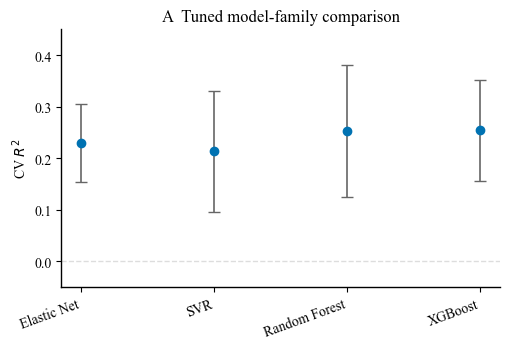

In [4]:
# Figure 3A draft plot
fig, ax = plt.subplots(figsize=(5.2, 3.6))

x = np.arange(len(fig3A_df))

ax.errorbar(
    x,
    fig3A_df["cv_r2_mean"],
    yerr=fig3A_df["cv_r2_std"],
    fmt="o",
    markersize=6,
    capsize=4,
    color=COLORS["blue"],
    ecolor=COLORS["gray"],
    elinewidth=1.2
)

ax.axhline(0, linestyle="--", linewidth=1, color=COLORS["light_gray"])

ax.set_xticks(x)
ax.set_xticklabels(fig3A_df["model"], rotation=20, ha="right")
ax.set_ylabel("CV $R^2$")
ax.set_title("A  Tuned model-family comparison")
ax.set_ylim(-0.05, 0.45)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## Part B — Figure 3B

In [5]:
# Model A vs Model B data
fig3B_df = pd.DataFrame({
    "model": ["Elastic Net", "Random Forest", "XGBoost", "SVR"],
    "model_A": [0.198247, 0.106106, -0.061187, -0.016650],
    "model_B": [0.266472, 0.185757, 0.006350, 0.000526],
})

fig3B_df["delta_B_minus_A"] = fig3B_df["model_B"] - fig3B_df["model_A"]

display(fig3B_df)

,model,model_A,model_B,delta_B_minus_A
0,Elastic Net,0.198247,0.266472,0.068225
1,Random Forest,0.106106,0.185757,0.079651
2,XGBoost,-0.061187,0.006350,0.067537
3,SVR,-0.016650,0.000526,0.017176


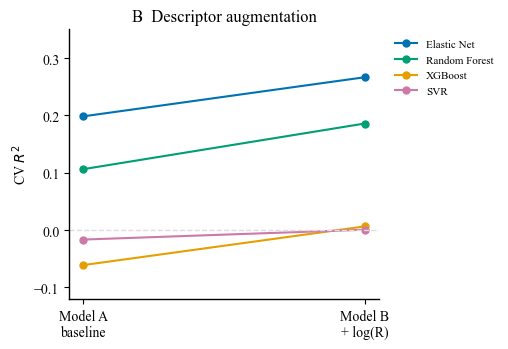

In [6]:
# Figure 3B draft plot
fig, ax = plt.subplots(figsize=(5.2, 3.6))

x_positions = [0, 1]

model_colors = {
    "Elastic Net": COLORS["blue"],
    "Random Forest": COLORS["green"],
    "XGBoost": COLORS["orange"],
    "SVR": COLORS["purple"],
}

for row in fig3B_df.itertuples():
    ax.plot(
        x_positions,
        [row.model_A, row.model_B],
        marker="o",
        markersize=5,
        linewidth=1.5,
        color=model_colors[row.model],
        label=row.model
    )

ax.axhline(0, linestyle="--", linewidth=1, color=COLORS["light_gray"])

ax.set_xticks(x_positions)
ax.set_xticklabels(["Model A\nbaseline", "Model B\n+ log(R)"])
ax.set_ylabel("CV $R^2$")
ax.set_title("B  Descriptor augmentation")
ax.set_ylim(-0.12, 0.35)

ax.legend(frameon=False, fontsize=8, loc="upper left", bbox_to_anchor=(1.02, 1.0))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## Part C — Figure 3C

In [7]:
# Feature-block ablation data
baseline_r2 = 0.197305

fig3C_df = pd.DataFrame({
    "removed_block": [
        "Mechanism labels",
        "Material class",
        "Ion type",
        "Internal resistance",
        "Structure"
    ],
    "setting": [
        "no_mechanism",
        "no_material",
        "no_ion_type",
        "no_internal_R",
        "no_structure"
    ],
    "r2_mean": [0.211431, 0.195296, 0.195181, 0.134244, 0.119046],
    "r2_std":  [0.146936, 0.153545, 0.148571, 0.192822, 0.160703],
    "delta_vs_baseline": [0.014126, -0.002009, -0.002124, -0.063061, -0.078258],
})

# Sort for lollipop plot
fig3C_plot_df = fig3C_df.sort_values("delta_vs_baseline", ascending=True).copy()

display(fig3C_df)

,removed_block,setting,r2_mean,r2_std,delta_vs_baseline
0,Mechanism labels,no_mechanism,0.211431,0.146936,0.014126
1,Material class,no_material,0.195296,0.153545,-0.002009
2,Ion type,no_ion_type,0.195181,0.148571,-0.002124
3,Internal resistance,no_internal_R,0.134244,0.192822,-0.063061
4,Structure,no_structure,0.119046,0.160703,-0.078258


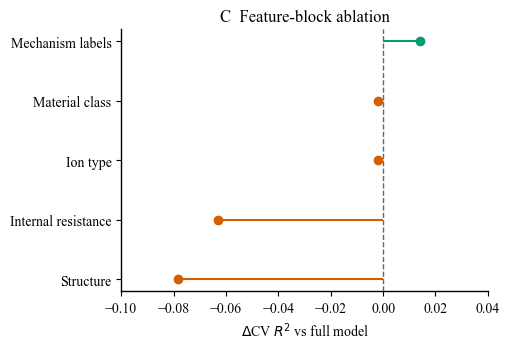

In [8]:
# Figure 3C draft plot
fig, ax = plt.subplots(figsize=(5.2, 3.6))

y = np.arange(len(fig3C_plot_df))

for i, row in enumerate(fig3C_plot_df.itertuples()):
    color = COLORS["vermillion"] if row.delta_vs_baseline < 0 else COLORS["green"]
    
    ax.hlines(
        y=i,
        xmin=0,
        xmax=row.delta_vs_baseline,
        linewidth=1.5,
        color=color
    )
    ax.plot(
        row.delta_vs_baseline,
        i,
        "o",
        markersize=6,
        color=color
    )

ax.axvline(0, linestyle="--", linewidth=1, color=COLORS["gray"])

ax.set_yticks(y)
ax.set_yticklabels(fig3C_plot_df["removed_block"])
ax.set_xlabel(r"$\Delta$CV $R^2$ vs full model")
ax.set_title("C  Feature-block ablation")

ax.set_xlim(-0.10, 0.04)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## Part D — Figure 3D

In [9]:
# SHAP descriptor importance data
fig3D_df = pd.DataFrame({
    "feature": [
        "log(R)",
        "Other cation",
        "Inorganic electrolyte",
        "Porous structure",
        "Film structure",
        "Ion-gradient label",
        "Streaming label",
        "Metal electrode",
        "Carboxyl/hydroxyl groups",
        "Semiconductor"
    ],
    "mean_abs_shap": [
        0.452154,
        0.132476,
        0.097737,
        0.095245,
        0.066256,
        0.063009,
        0.050077,
        0.035731,
        0.027268,
        0.024974
    ]
})

fig3D_plot_df = fig3D_df.sort_values("mean_abs_shap", ascending=True).copy()

display(fig3D_df)

,feature,mean_abs_shap
0,log(R),0.452154
1,Other cation,0.132476
2,Inorganic electrolyte,0.097737
3,Porous structure,0.095245
4,Film structure,0.066256
5,Ion-gradient label,0.063009
6,Streaming label,0.050077
7,Metal electrode,0.035731
8,Carboxyl/hydroxyl groups,0.027268
9,Semiconductor,0.024974


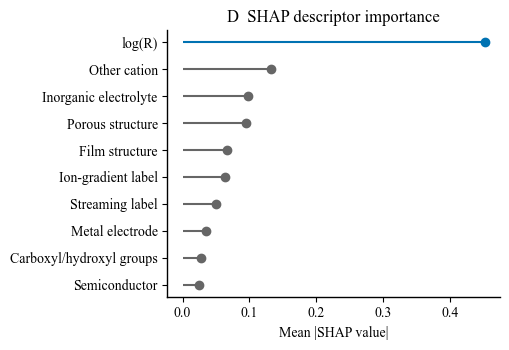

In [10]:
# Figure 3D draft plot
fig, ax = plt.subplots(figsize=(5.2, 3.6))

y = np.arange(len(fig3D_plot_df))

for i, row in enumerate(fig3D_plot_df.itertuples()):
    color = COLORS["blue"] if row.feature == "log(R)" else COLORS["gray"]
    
    ax.hlines(
        y=i,
        xmin=0,
        xmax=row.mean_abs_shap,
        linewidth=1.5,
        color=color
    )
    ax.plot(
        row.mean_abs_shap,
        i,
        "o",
        markersize=6,
        color=color
    )

ax.set_yticks(y)
ax.set_yticklabels(fig3D_plot_df["feature"])
ax.set_xlabel("Mean |SHAP value|")
ax.set_title("D  SHAP descriptor importance")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## Part E — Combined Figure 3 draft

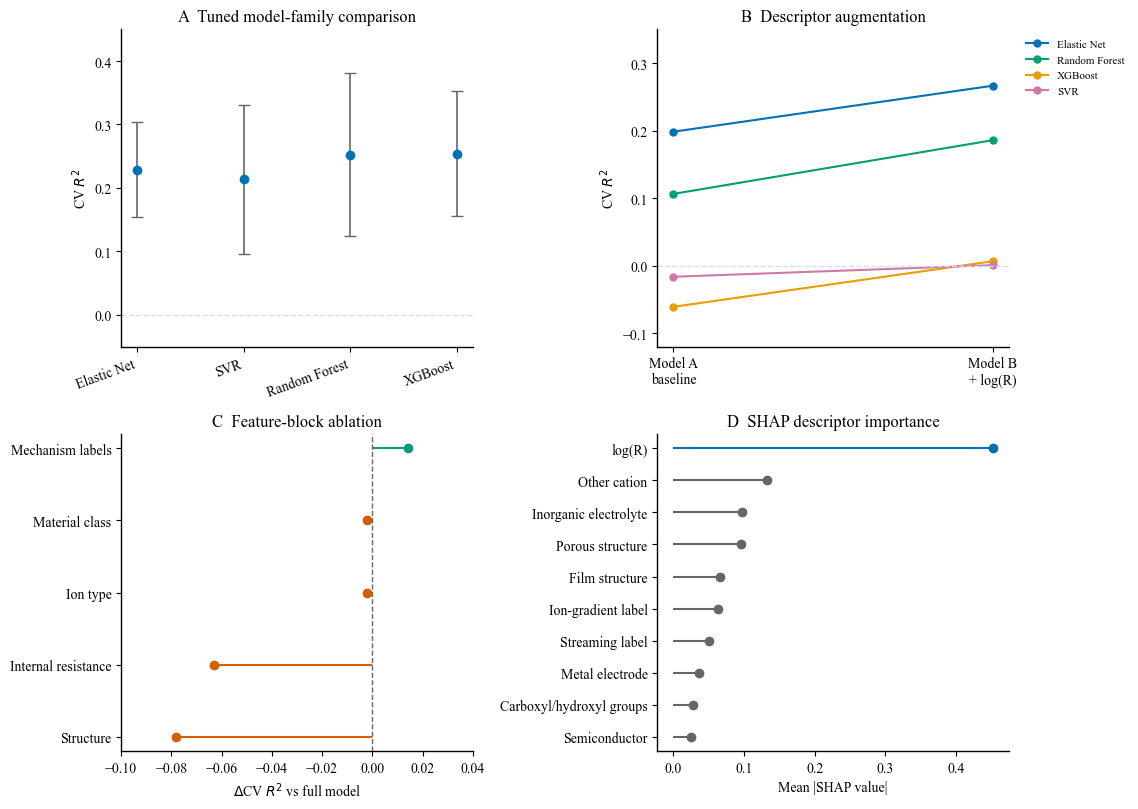

In [11]:
# Combined 2 × 2 draft
fig, axes = plt.subplots(2, 2, figsize=(11.5, 8.2))

# =========================
# A. Tuned model comparison
# =========================
ax = axes[0, 0]
x = np.arange(len(fig3A_df))

ax.errorbar(
    x,
    fig3A_df["cv_r2_mean"],
    yerr=fig3A_df["cv_r2_std"],
    fmt="o",
    markersize=6,
    capsize=4,
    color=COLORS["blue"],
    ecolor=COLORS["gray"],
    elinewidth=1.2
)

ax.axhline(0, linestyle="--", linewidth=1, color=COLORS["light_gray"])
ax.set_xticks(x)
ax.set_xticklabels(fig3A_df["model"], rotation=20, ha="right")
ax.set_ylabel("CV $R^2$")
ax.set_title("A  Tuned model-family comparison")
ax.set_ylim(-0.05, 0.45)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


# =========================
# B. Model A vs Model B
# =========================
ax = axes[0, 1]

for row in fig3B_df.itertuples():
    ax.plot(
        [0, 1],
        [row.model_A, row.model_B],
        marker="o",
        markersize=5,
        linewidth=1.5,
        color=model_colors[row.model],
        label=row.model
    )

ax.axhline(0, linestyle="--", linewidth=1, color=COLORS["light_gray"])
ax.set_xticks([0, 1])
ax.set_xticklabels(["Model A\nbaseline", "Model B\n+ log(R)"])
ax.set_ylabel("CV $R^2$")
ax.set_title("B  Descriptor augmentation")
ax.set_ylim(-0.12, 0.35)
ax.legend(frameon=False, fontsize=8, loc="upper left", bbox_to_anchor=(1.02, 1.0))
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


# =========================
# C. Feature-block ablation
# =========================
ax = axes[1, 0]

y = np.arange(len(fig3C_plot_df))

for i, row in enumerate(fig3C_plot_df.itertuples()):
    color = COLORS["vermillion"] if row.delta_vs_baseline < 0 else COLORS["green"]
    ax.hlines(
        y=i,
        xmin=0,
        xmax=row.delta_vs_baseline,
        linewidth=1.5,
        color=color
    )
    ax.plot(
        row.delta_vs_baseline,
        i,
        "o",
        markersize=6,
        color=color
    )

ax.axvline(0, linestyle="--", linewidth=1, color=COLORS["gray"])
ax.set_yticks(y)
ax.set_yticklabels(fig3C_plot_df["removed_block"])
ax.set_xlabel(r"$\Delta$CV $R^2$ vs full model")
ax.set_title("C  Feature-block ablation")
ax.set_xlim(-0.10, 0.04)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


# =========================
# D. SHAP descriptor importance
# =========================
ax = axes[1, 1]

y = np.arange(len(fig3D_plot_df))

for i, row in enumerate(fig3D_plot_df.itertuples()):
    color = COLORS["blue"] if row.feature == "log(R)" else COLORS["gray"]
    ax.hlines(
        y=i,
        xmin=0,
        xmax=row.mean_abs_shap,
        linewidth=1.5,
        color=color
    )
    ax.plot(
        row.mean_abs_shap,
        i,
        "o",
        markersize=6,
        color=color
    )

ax.set_yticks(y)
ax.set_yticklabels(fig3D_plot_df["feature"])
ax.set_xlabel("Mean |SHAP value|")
ax.set_title("D  SHAP descriptor importance")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

# Save draft figure
fig.savefig(out_dir / "figure3_model_comparison_draft.png", dpi=300, bbox_inches="tight")
fig.savefig(out_dir / "figure3_model_comparison_draft.pdf", bbox_inches="tight")

plt.show()

## Part F — Export CSV files for Igor Pro

In [12]:
# Export data
fig3A_df.to_csv(out_dir / "fig3A_tuned_model_comparison.csv", index=False, encoding="utf-8-sig")
fig3B_df.to_csv(out_dir / "fig3B_modelA_modelB_descriptor_augmentation.csv", index=False, encoding="utf-8-sig")
fig3C_df.to_csv(out_dir / "fig3C_feature_block_ablation.csv", index=False, encoding="utf-8-sig")
fig3D_df.to_csv(out_dir / "fig3D_SHAP_descriptor_importance.csv", index=False, encoding="utf-8-sig")

print("Exported files:")
for f in sorted(out_dir.glob("*")):
    print(f.name)

Exported files:
fig3A_tuned_model_comparison.csv
fig3B_modelA_modelB_descriptor_augmentation.csv
fig3C_feature_block_ablation.csv
fig3D_SHAP_descriptor_importance.csv
figure3_model_comparison_draft.pdf
figure3_model_comparison_draft.png


## Figure 3 summary

Figure 3 summarizes model comparison and descriptor dominance.

- Fig. 3A shows that tuned model families converge to comparable moderate CV R² values.
- Fig. 3B shows that adding internal resistance to the mechanistic baseline improves model performance across model families.
- Fig. 3C shows that removal of structure and internal resistance causes the largest reduction in model performance.
- Fig. 3D shows that log(R) is the dominant individual descriptor according to SHAP importance.

Together, these results support the transition from categorical mechanism labels to transport-centered descriptor analysis.